In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd

Mounted at /content/drive


In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patches as patches
import matplotlib.patheffects as pe
import matplotlib.gridspec as gridspec

from matplotlib.colors import TwoSlopeNorm
from matplotlib.gridspec import GridSpec
from matplotlib.patches import FancyBboxPatch, Arc, Circle, FancyArrowPatch

from scipy.stats import gaussian_kde
from scipy.ndimage import gaussian_filter

In [ ]:
events_df  = pd.read_csv('/content/drive/MyDrive/HALO Hackathon/events_with_corrected_epv.csv')
players_df = pd.read_csv('/content/drive/MyDrive/HALO Hackathon/players(in).csv')

In [ ]:
print(events_df['team'].unique())

['GR' 'CLE' 'IA' 'CHI' 'TEX' 'PRO' 'WBS' 'COL' 'SPR' 'CLT' 'HER' 'CAL'
 'SJ' 'RFD' 'HEN' 'ABB' 'LAV' 'BRI' 'BAK' 'CVF' 'TUC' 'TOR' 'BEL' 'MIL'
 'SYC' 'LV' 'MB' 'HFD' 'UTC' 'SD' 'RCH' 'ONT']


In [ ]:
THEME = {
    'bg':         '#0D1117',
    'panel':      '#161B22',
    'panel2':     '#1C2330',
    'border':     '#30363D',
    'gold':       '#E8B84B',
    'gold_dim':   '#8B6914',
    'navy':       '#1F4E8C',
    'navy_bright':'#2D72D2',
    'red':        '#CF3030',
    'green':      '#2EA84B',
    'text':       '#E6EDF3',
    'text_dim':   '#8B949E',
    'text_faint': '#484F58',
    'white':      '#FFFFFF',
    'accent':     '#58A6FF',
}

EVENT_TYPE_LABELS = {
    'faceoff':               'Faceoff',
    'pass':                  'Pass',
    'reception':             'Reception',
    'shot':                  'Shot',
    'lpr':                   'LPR',
    'carry':                 'Carry',
    'dumpout':               'Dump Out',
    'dumpin':                'Dump In',
    'puckprotection':        'Puck Prot.',
    'controlledbreakout':    'Ctrl Breakout',
    'controlledentryagainst':'Ctrl Entry Agnst',
    'check':                 'Check',
    'block':                 'Block',
    'pressure':              'Pressure',
    'deflection':            'Deflection',
}


def draw_half_rink(ax, linewidth=1.2, alpha=1.0):
    ax.set_xlim(0, 100)
    ax.set_ylim(-42.5, 42.5)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_facecolor('#0d1f30')
    lc = '#6AABCC'
    lw = linewidth
    ax.add_patch(patches.FancyBboxPatch(
        (0, -42.5), 100, 85, boxstyle="round,pad=0",
        linewidth=lw * 2, edgecolor='#88CCEE', facecolor='#0d1f30', alpha=1.0, zorder=1
    ))
    ax.fill_between([89, 100], [-6, -6], [6, 6], color='#1A3A5A', alpha=0.7, zorder=2)
    ax.add_patch(patches.Arc((89, 0), 14, 14, angle=0, theta1=270, theta2=90,
                              color='#55DDFF', lw=lw * 2, zorder=5))
    ax.add_patch(patches.Rectangle((89, -3), 3, 6,
                 linewidth=lw * 2, edgecolor='#FFE566', facecolor='none', zorder=6))
    ax.plot([89, 89], [-10, 10], color='#FF5555', lw=lw * 2.5, zorder=4)
    ax.plot([25, 25], [-42.5, 42.5], color='#55AAFF', lw=lw * 3, zorder=4)
    ax.plot([0, 0], [-42.5, 42.5], color='#FF5555', lw=lw * 2, zorder=4)
    for y in [-22, 22]:
        ax.add_patch(Circle((69, y), 1.8, color='#FF5555', fill=True, zorder=5))
        ax.add_patch(Arc((69, y), 30, 30, angle=0, theta1=0, theta2=360,
                         color=lc, lw=lw * 1.2, zorder=4))
    for y in [-22, 22]:
        ax.add_patch(Circle((20, y), 1.8, color='#FF5555', fill=True, zorder=5))


def compute_player_stats(events_df, player_name):
    if player_name not in events_df['player_name'].values:
        available = list(events_df['player_name'].unique()[:10])
        raise ValueError(
            f"Player '{player_name}' not found.\n"
            f"First 10 available: {available}\n"
            "Tip: copy the exact name from events_df['player_name'].unique()"
        )
    pdf = events_df[events_df['player_name'] == player_name].copy()
    player_totals = events_df.groupby('player_name')['delta_EPV'].sum()
    player_epv    = player_totals.get(player_name, 0)
    pct_rank      = int((player_totals < player_epv).mean() * 100)
    event_stats = {}
    all_players_event = (
        events_df.groupby(['player_name', 'event_type'])['delta_EPV']
        .mean().reset_index()
    )
    for et, label in EVENT_TYPE_LABELS.items():
        player_et = pdf[pdf['event_type'] == et]['delta_EPV']
        if len(player_et) < 3:
            continue
        all_means = all_players_event[all_players_event['event_type'] == et]['delta_EPV']
        if len(all_means) < 2:
            continue
        player_mean = player_et.mean()
        global_std  = all_means.std()
        z_score     = (player_mean - all_means.mean()) / global_std if global_std > 0 else 0
        et_pct      = int((all_means < player_mean).mean() * 100)
        event_stats[et] = {
            'label':      label,
            'mean_epv':   player_mean,
            'z_score':    z_score,
            'percentile': et_pct,
            'n':          len(player_et),
        }
    if 'game_id' in pdf.columns:
        game_epv = pdf.groupby('game_id')['delta_EPV'].sum().values
    else:
        game_epv = np.array([])
    if len(game_epv) > 1:
        window = max(2, len(game_epv) // 5)
        ma = np.convolve(game_epv, np.ones(window) / window, mode='valid')
    else:
        ma = game_epv.copy()
    shots        = pdf[pdf['event_type'] == 'shot'][['x_adj', 'y_adj']].dropna()
    gp           = pdf['game_id'].nunique() if 'game_id' in pdf.columns else 0
    goals        = int((pdf['event_type'] == 'goal').sum())
    assists      = int((pdf['event_type'] == 'assist').sum())
    points       = goals + assists
    total_epv    = float(pdf['delta_EPV'].sum())
    total_events = len(pdf)
    return {
        'player_name':    player_name,
        'epv_percentile': pct_rank,
        'total_epv':      total_epv,
        'event_stats':    event_stats,
        'game_epv':       game_epv,
        'moving_avg':     ma,
        'shots':          shots,
        'gp':             gp,
        'goals':          goals,
        'assists':        assists,
        'points':         points,
        'total_events':   total_events,
    }


def get_player_info(players_df, player_name):
    if players_df is None or players_df.empty:
        return {}
    if 'player_name' in players_df.columns:
        row = players_df[players_df['player_name'] == player_name]
        if not row.empty:
            return row.iloc[0].to_dict()
    last = player_name.split(',')[0].strip()
    if 'last_name' in players_df.columns:
        row = players_df[players_df['last_name'] == last]
        if not row.empty:
            return row.iloc[0].to_dict()
    return {}


def draw_header(ax, stats, player_info, team_name=""):
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')
    ax.set_facecolor(THEME['panel'])
    ax.add_patch(patches.Rectangle(
        (0, 0), 0.004, 1, color=THEME['gold'],
        transform=ax.transAxes, clip_on=False, zorder=10
    ))
    ax.text(0.05, 0.72, stats['player_name'], transform=ax.transAxes,
            ha='left', va='center', fontsize=20, fontweight='bold',
            color=THEME['text'], fontfamily='monospace')
    pos   = player_info.get('primary_position', player_info.get('position_group', ''))
    hand  = player_info.get('handed', '')
    bdate = player_info.get('birth_date', '')
    parts = []
    if pos:       parts.append(f"POS: {pos}")
    if hand:      parts.append(f"Shoots: {str(hand).upper()}")
    if bdate:     parts.append(f"DOB: {bdate}")
    if team_name: parts.append(str(team_name))
    ax.text(0.05, 0.30, "  |  ".join(parts), transform=ax.transAxes,
            ha='left', va='center', fontsize=12,
            color=THEME['white'], fontfamily='monospace')
    ax.plot([0.02, 0.98], [0.12, 0.12], color=THEME['border'],
            transform=ax.transAxes, lw=0.5, alpha=0.6)
    # ── PVA Percentile (left of center) ──
    ax.text(0.46, 0.82, 'PVA PERC.', transform=ax.transAxes,
            ha='center', fontsize=10, color=THEME['white'],
            fontfamily='monospace', fontweight='bold')
    pct       = stats['epv_percentile']
    pct_color = THEME['green'] if pct >= 50 else THEME['red']
    ax.text(0.46, 0.38, f"{pct}%", transform=ax.transAxes,
            ha='center', va='center', fontsize=22, fontweight='bold',
            color=pct_color, fontfamily='monospace')

    # ── Season Stats (right section) ──
    ax.text(0.76, 0.82, 'SEASON STATS', transform=ax.transAxes,
            ha='center', fontsize=10, color=THEME['white'],
            fontfamily='monospace', fontweight='bold')
    col_labels = ['GP',             'G',               'A',               'PTS',             'PVA+']
    col_values = [str(stats['gp']), str(stats['goals']), str(stats['assists']),
                  str(stats['points']), f"{stats['total_epv']:+.3f}"]
    col_x      = [0.57, 0.65, 0.72, 0.79, 0.90]
    for cx, cl, cv in zip(col_x, col_labels, col_values):
        ax.text(cx, 0.65, cl, transform=ax.transAxes,
                ha='center', fontsize=10, color=THEME['white'], fontfamily='monospace')
        color = THEME['green'] if cl == 'PVA+' and stats['total_epv'] >= 0 else (
                THEME['red']  if cl == 'PVA+' else THEME['text'])
        ax.text(cx, 0.36, cv, transform=ax.transAxes,
                ha='center', va='center', fontsize=14, fontweight='bold',
                color=color, fontfamily='monospace')
    ax.text(0.76, 0.10, f"{stats['total_events']} events tracked",
            transform=ax.transAxes, ha='center', fontsize=8,
            color=THEME['white'], fontfamily='monospace')


def draw_event_bars(ax, event_stats):
    ax.set_facecolor(THEME['panel'])
    for sp in ax.spines.values():
        sp.set_visible(False)
    ax.text(0.5, 1.03, 'PVA per Event Type', transform=ax.transAxes,
            ha='center', va='bottom', fontsize=9, fontweight='bold',
            color=THEME['white'], fontfamily='monospace')
    if not event_stats:
        ax.text(0.5, 0.5, 'Insufficient data', transform=ax.transAxes,
                ha='center', va='center', color=THEME['text_dim'], fontsize=9)
        return
    items    = sorted(event_stats.items(), key=lambda x: x[1]['z_score'])
    labels   = [v['label']      for _, v in items]
    z_scores = [v['z_score']    for _, v in items]
    pcts     = [v['percentile'] for _, v in items]
    y_pos    = np.arange(len(labels))
    ax.axvline(0, color=THEME['border'], lw=1, zorder=1)
    for i, (z, pct) in enumerate(zip(z_scores, pcts)):
        color = THEME['navy_bright'] if z >= 0 else THEME['gold']
        alpha = min(0.3 + abs(z) * 0.25, 1.0)
        ax.barh(i, z, height=0.55, color=color, alpha=alpha, zorder=2)
        x_off = 0.06 if z >= 0 else -0.06
        ax.text(z + x_off, i, f"{pct}%",
                va='center', ha='left' if z >= 0 else 'right',
                fontsize=7, color=THEME['text'],
                fontfamily='monospace', fontweight='bold', zorder=3)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels, fontsize=9, color=THEME['white'], fontfamily='monospace')
    ax.tick_params(axis='y', length=0, pad=4)
    ax.tick_params(axis='x', colors=THEME['white'], labelsize=8)
    ax.set_xlabel('Std. Deviation vs League', fontsize=8.5,
                  color=THEME['white'], fontfamily='monospace', labelpad=4)
    xlim = max(0.5, max(abs(z) for z in z_scores) * 1.35)
    ax.set_xlim(-xlim, xlim)
    ax.text(1.01, 1.01, 'Perc.', transform=ax.transAxes,
            ha='left', va='bottom', fontsize=8.5,
            color=THEME['white'], fontfamily='monospace')
    ax.xaxis.grid(True, color=THEME['text_faint'], alpha=0.15, lw=0.5, zorder=0)
    ax.set_axisbelow(True)
    ax.set_facecolor(THEME['panel'])


def draw_moving_average(ax, game_epv, moving_avg):
    ax.set_facecolor(THEME['panel'])
    for sp in ax.spines.values():
        sp.set_color(THEME['border'])
        sp.set_linewidth(0.5)
    ax.text(0.5, 1.03, 'Moving Avg PVA per Game', transform=ax.transAxes,
            ha='center', va='bottom', fontsize=9, fontweight='bold',
            color=THEME['white'], fontfamily='monospace')
    if len(game_epv) < 2:
        ax.text(0.5, 0.5, 'Insufficient game data', transform=ax.transAxes,
                ha='center', va='center', color=THEME['white'], fontsize=8)
        ax.set_facecolor(THEME['panel'])
        return
    x_game = np.arange(len(game_epv))
    x_ma   = np.arange(len(moving_avg)) + (len(game_epv) - len(moving_avg)) / 2
    ax.axhline(0, color=THEME['border'], lw=0.8, alpha=0.8)
    ax.bar(x_game, game_epv,
           color=[THEME['navy_bright'] if v >= 0 else THEME['gold'] for v in game_epv],
           alpha=0.25, width=0.7, zorder=2)
    ax.plot(x_ma, moving_avg, color=THEME['accent'], lw=1.5, zorder=3, label='Rolling Avg')
    ax.fill_between(x_ma, moving_avg, 0, alpha=0.07, color=THEME['accent'], zorder=2)
    ax.axhline(np.mean(game_epv), color=THEME['text_dim'], lw=0.8,
               ls='--', alpha=0.5, label='Season Avg')
    ax.tick_params(colors=THEME['white'], labelsize=8)
    ax.set_xlabel('Game', fontsize=8.5, color=THEME['white'],
                  fontfamily='monospace', labelpad=3)
    ax.set_ylabel('PVA', fontsize=8.5, color=THEME['white'],
                  fontfamily='monospace', labelpad=3)
    ax.legend(fontsize=8, loc='upper right', framealpha=0.2,
              labelcolor=THEME['white'], facecolor=THEME['panel2'],
              edgecolor=THEME['border'])
    ax.xaxis.grid(True, color=THEME['text_faint'], alpha=0.1, lw=0.4)
    ax.yaxis.grid(True, color=THEME['text_faint'], alpha=0.1, lw=0.4)
    ax.set_axisbelow(True)
    ax.set_facecolor(THEME['panel'])


def draw_shot_map(ax, shots_df):
    draw_half_rink(ax)
    ax.text(0.5, 1.03, 'Shot Map', transform=ax.transAxes,
            ha='center', va='bottom', fontsize=9, fontweight='bold',
            color=THEME['white'], fontfamily='monospace')
    if len(shots_df) < 3:
        ax.text(50, 0, f"n={len(shots_df)} (need >=3)",
                ha='center', va='center', fontsize=7, color=THEME['white'])
        return
    xs = np.abs(shots_df['x_adj'].values)
    ys = shots_df['y_adj'].values
    xi, yi = np.linspace(0, 100, 150), np.linspace(-42.5, 42.5, 100)
    xi2d, yi2d = np.meshgrid(xi, yi)
    try:
        kde = gaussian_kde(np.vstack([xs, ys]), bw_method=0.3)
        zi  = gaussian_filter(
            kde(np.vstack([xi2d.ravel(), yi2d.ravel()])).reshape(xi2d.shape), sigma=2)
        ax.contourf(xi, yi, zi, levels=12, cmap='YlOrRd', alpha=0.55, zorder=5)
    except Exception:
        pass
    ax.scatter(xs, ys, s=8, c=THEME['gold'], alpha=0.5, zorder=6, edgecolors='none')
    ax.text(2, -40, f'n={len(xs)}', fontsize=7.5,
            color=THEME['white'], fontfamily='monospace', zorder=8)


def draw_pass_locations(ax, events_df, player_name):
    draw_half_rink(ax)
    ax.text(0.5, 1.03, 'Pass Locations', transform=ax.transAxes,
            ha='center', va='bottom', fontsize=9, fontweight='bold',
            color=THEME['white'], fontfamily='monospace')
    pass_df = events_df[
        (events_df['player_name'] == player_name) &
        (events_df['event_type']  == 'pass')
    ][['x_adj', 'y_adj']].dropna()
    if len(pass_df) < 3:
        ax.text(50, 0, f"n={len(pass_df)} (need >=3)",
                ha='center', va='center', fontsize=7, color=THEME['white'])
        return
    xs = np.abs(pass_df['x_adj'].values)
    ys = pass_df['y_adj'].values
    xi, yi = np.linspace(0, 100, 120), np.linspace(-42.5, 42.5, 80)
    xi2d, yi2d = np.meshgrid(xi, yi)
    try:
        kde = gaussian_kde(np.vstack([xs, ys]), bw_method=0.35)
        zi  = gaussian_filter(
            kde(np.vstack([xi2d.ravel(), yi2d.ravel()])).reshape(xi2d.shape), sigma=2)
        ax.contourf(xi, yi, zi, levels=10, cmap='Blues', alpha=0.5, zorder=5)
    except Exception:
        pass
    ax.scatter(xs, ys, s=5, c=THEME['accent'], alpha=0.35, zorder=6, edgecolors='none')
    ax.text(2, -40, f'n={len(pass_df)}', fontsize=7.5,
            color=THEME['white'], fontfamily='monospace', zorder=8)


def draw_zone_entry_dist(ax, events_df, player_name):
    ax.set_facecolor(THEME['panel'])
    for sp in ax.spines.values():
        sp.set_color(THEME['border'])
        sp.set_linewidth(0.5)
    ax.text(0.02, 1.03, 'Zone Entry Distribution (vs Lg Avg)',
            transform=ax.transAxes, ha='left', va='bottom',
            fontsize=9, fontweight='bold', color=THEME['white'], fontfamily='monospace')
    entry_events   = ['carry', 'dumpin', 'controlledbreakout']
    player_entries = events_df[
        (events_df['player_name'] == player_name) &
        (events_df['event_type'].isin(entry_events))
    ]['y_adj'].dropna()
    all_entries = events_df[
        events_df['event_type'].isin(entry_events)
    ]['y_adj'].dropna()
    bins        = np.linspace(-42.5, 42.5, 18)
    bin_centers = (bins[:-1] + bins[1:]) / 2
    if len(player_entries) > 2 and len(all_entries) > 2:
        p_hist, _ = np.histogram(player_entries, bins=bins, density=True)
        l_hist, _ = np.histogram(all_entries,    bins=bins, density=True)
        diff      = p_hist - l_hist
        ax.bar(bin_centers, diff, width=(bins[1] - bins[0]) * 0.85,
               color=[THEME['navy_bright'] if d >= 0 else THEME['gold'] for d in diff],
               alpha=0.75, zorder=2)
        ax.axhline(0, color=THEME['border'], lw=0.8)
        ax.set_xlabel('Y Position (ft)', fontsize=8.5,
                      color=THEME['white'], fontfamily='monospace')
        ax.set_ylabel('Rel. Freq.', fontsize=8,
                      color=THEME['white'], fontfamily='monospace')
    else:
        ax.text(0.5, 0.5, 'Insufficient entry data', transform=ax.transAxes,
                ha='center', va='center', color=THEME['text_dim'], fontsize=7.5)
    ax.tick_params(colors=THEME['white'], labelsize=8)
    ax.yaxis.grid(True, color=THEME['text_faint'], alpha=0.1, lw=0.4)
    ax.set_axisbelow(True)
    ax.set_facecolor(THEME['panel'])


def generate_player_card(
    events_df:   pd.DataFrame,
    player_name: str = None,
    players_df:  pd.DataFrame = None,
    team_name:   str = "",
    output_path: str = None,
    show:        bool = True,
) -> plt.Figure:
    """
    Generate a professional PVA player analytics card.

    If player_name is None, picks a random player from events_df.
    """
    if 'player_name' not in events_df.columns:
        raise KeyError(
            "'player_name' column not found in events_df.\n"
            f"Columns present: {list(events_df.columns)}\n"
            "Fix: load with pd.read_csv('file.csv', index_col=0)"
        )

    # Pick random player if none specified
    if player_name is None:
        player_name = np.random.choice(events_df['player_name'].unique())
        print(f"Random player selected: {player_name}")

    stats       = compute_player_stats(events_df, player_name)
    player_info = get_player_info(players_df, player_name) if players_df is not None else {}

    fig = plt.figure(figsize=(14, 9), facecolor=THEME['bg'])
    fig.patch.set_facecolor(THEME['bg'])

    gs_outer = GridSpec(
        2, 2, figure=fig,
        height_ratios=[1, 4.2],
        width_ratios=[1, 1.35],
        hspace=0.10, wspace=0.08,
        left=0.03, right=0.97, top=0.95, bottom=0.05,
    )

    ax_header = fig.add_subplot(gs_outer[0, :])
    ax_bars   = fig.add_subplot(gs_outer[1, 0])
    gs_right  = gs_outer[1, 1].subgridspec(2, 2, hspace=0.38, wspace=0.28)
    ax_ma     = fig.add_subplot(gs_right[0, :])
    ax_shot   = fig.add_subplot(gs_right[1, 0])
    ax_pass   = fig.add_subplot(gs_right[1, 1])

    for ax in [ax_header, ax_bars, ax_ma]:
        ax.set_facecolor(THEME['panel'])

    draw_header(ax_header, stats, player_info, team_name)
    draw_event_bars(ax_bars, stats['event_stats'])
    draw_moving_average(ax_ma, stats['game_epv'], stats['moving_avg'])
    draw_shot_map(ax_shot, stats['shots'])
    draw_pass_locations(ax_pass, events_df, player_name)

    for ax in [ax_bars, ax_ma, ax_shot, ax_pass]:
        for sp in ax.spines.values():
            sp.set_edgecolor(THEME['border'])
            sp.set_linewidth(0.5)

    fig.text(0.97, 0.015, 'PVA Analytics  |  All stats vs. league',
             ha='right', va='bottom', fontsize=6,
             color=THEME['text_faint'], fontfamily='monospace', alpha=0.6)

    if output_path:
        fig.savefig(output_path, dpi=150, bbox_inches='tight', facecolor=THEME['bg'])
        print(f"Saved: {output_path}")

    if show:
        plt.show()

    return fig


# ── Run this block directly in your notebook ──
# Paste the whole file into one cell, then add a new cell with:
#
#   fig = generate_player_card(events_df=events_df, players_df=player_df)
#
# Or for a specific player:
#   fig = generate_player_card(events_df=events_df, players_df=player_df,
#                              player_name="McKown, Hunter")


# ─────────────────────────────────────────────
#  PASS SPATIAL MAP — Time Since Entry
#  Based on: "Pass to Pass ES Entry Time AR(1) INLA Spatial Map"
#  Shows relative pass frequency by ice location across 4 time windows
#  Side by side: league-wide (left) vs single player (right)
# ─────────────────────────────────────────────

def _build_pass_kde_grid(pass_df, xi2d, yi2d, bw=0.15):
    """
    Build a KDE density grid from pass x/y locations.
    Returns a normalized grid or None if insufficient data.
    """
    xs = np.abs(pass_df['x_adj'].values)   # mirror to offensive half
    ys = pass_df['y_adj'].values
    if len(xs) < 5:
        return None
    try:
        kde = gaussian_kde(np.vstack([xs, ys]), bw_method=bw)
        zi  = kde(np.vstack([xi2d.ravel(), yi2d.ravel()])).reshape(xi2d.shape)
        zi  = gaussian_filter(zi, sigma=1.5)
        # Normalize to 0-1 so panels are comparable
        zi  = (zi - zi.min()) / (zi.max() - zi.min() + 1e-12)
        return zi
    except Exception:
        return None


def _draw_rink_outline(ax):
    """Draw a clean half-rink outline for the spatial map panels."""
    ax.set_xlim(0, 100)
    ax.set_ylim(-42.5, 42.5)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_facecolor('#1a0a2e')   # dark purple base matching colormap

    lw = 1.0
    # Boards
    ax.add_patch(patches.FancyBboxPatch(
        (0, -42.5), 100, 85, boxstyle="round,pad=0",
        linewidth=lw * 1.5, edgecolor='#AAAACC',
        facecolor='none', zorder=8
    ))
    # Blue line
    ax.plot([25, 25], [-42.5, 42.5], color='#7799FF',
            lw=lw * 2, zorder=7, alpha=0.8)
    # Goal line
    ax.plot([89, 89], [-10, 10], color='#FF6666',
            lw=lw * 2, zorder=7, alpha=0.8)
    # Goal crease
    ax.add_patch(patches.Arc((89, 0), 14, 14, angle=0,
                              theta1=270, theta2=90,
                              color='#88DDFF', lw=lw * 1.5, zorder=8))
    # Goal posts
    ax.add_patch(patches.Rectangle(
        (89, -3), 3, 6,
        linewidth=lw * 1.5, edgecolor='#FFE566',
        facecolor='none', zorder=9
    ))
    # Faceoff dots
    for y in [-22, 22]:
        ax.add_patch(Circle((69, y), 1.5,
                            color='#FF6666', fill=True, zorder=8))
        ax.add_patch(Arc((69, y), 28, 28, angle=0,
                         theta1=0, theta2=360,
                         color='#AAAACC', lw=lw * 0.8, zorder=7))
    for y in [-22, 22]:
        ax.add_patch(Circle((20, y), 1.5,
                            color='#FF6666', fill=True, zorder=8))


def generate_pass_spatial_map(
    events_df:   pd.DataFrame,
    player_name: str,
    time_windows: list = None,
    output_path:  str  = None,
    show:         bool = True,
) -> plt.Figure:
    """
    Generate a 2×4 grid spatial map of pass frequency by time since zone entry.
    Left column = league-wide, Right column = single player.
    4 rows = time windows (0-2s, 3-5s, 6-10s, 11+s).

    Parameters
    ----------
    events_df    : Full events DataFrame with x_adj, y_adj,
                   time_since_entry, event_type, player_name columns.
    player_name  : Player to show on the right column.
    time_windows : List of (label, min_t, max_t) tuples. Defaults to
                   [(0-2s), (3-5s), (6-10s), (11+s)].
    output_path  : Optional path to save PNG.
    show         : If True, calls plt.show() for inline display.

    Usage
    -----
    fig = generate_pass_spatial_map(
        events_df   = events_df,
        player_name = "McKown, Hunter",
        show        = True,
    )
    """

    if time_windows is None:
        time_windows = [
            ('0–2 Seconds After Entry',  0,   2),
            ('3–5 Seconds After Entry',  3,   5),
            ('6–10 Seconds After Entry', 6,  10),
            ('11+ Seconds After Entry', 11, 9999),
        ]

    n_windows = len(time_windows)

    # ── Filter to passes only ──
    all_passes    = events_df[events_df['event_type'] == 'pass'].copy()
    player_passes = all_passes[all_passes['player_name'] == player_name].copy()

    # ── Build KDE grid coordinates ──
    xi   = np.linspace(0, 100, 140)
    yi   = np.linspace(-42.5, 42.5, 100)
    xi2d, yi2d = np.meshgrid(xi, yi)

    # ── Figure layout: n_windows rows × 2 cols ──
    fig, axes = plt.subplots(
        n_windows, 2,
        figsize=(10, n_windows * 3.2),
        facecolor='#0D1117'
    )
    fig.patch.set_facecolor('#0D1117')

    # Ensure axes is always 2D
    if n_windows == 1:
        axes = axes[np.newaxis, :]

    # Column titles
    col_titles = ['League-Wide', player_name]
    for col, title in enumerate(col_titles):
        axes[0, col].set_title(
            title, fontsize=11, fontweight='bold',
            color='white', fontfamily='monospace', pad=8
        )

    # ── Colormap: plasma reversed gives purple→yellow ──
    cmap = plt.cm.plasma

    # Collect all grids first so we can set a shared vmax
    all_grids = []
    for label, t_min, t_max in time_windows:
        w_all = all_passes[
            (all_passes['time_since_entry'] >= t_min) &
            (all_passes['time_since_entry'] <= t_max)
        ]
        w_player = player_passes[
            (player_passes['time_since_entry'] >= t_min) &
            (player_passes['time_since_entry'] <= t_max)
        ]
        all_grids.append((
            label,
            _build_pass_kde_grid(w_all,    xi2d, yi2d, bw=0.12),
            _build_pass_kde_grid(w_player, xi2d, yi2d, bw=0.18),
            len(w_all),
            len(w_player),
        ))

    for row, (label, grid_league, grid_player, n_league, n_player) in enumerate(all_grids):

        for col, (grid, n) in enumerate([
            (grid_league, n_league),
            (grid_player, n_player),
        ]):
            ax = axes[row, col]
            _draw_rink_outline(ax)

            if grid is not None:
                im = ax.contourf(
                    xi, yi, grid,
                    levels=14,
                    cmap=cmap,
                    alpha=0.82,
                    zorder=3,
                    vmin=0, vmax=1,
                )
                # Subtle contour lines
                ax.contour(
                    xi, yi, grid,
                    levels=7,
                    colors='white',
                    alpha=0.12,
                    linewidths=0.4,
                    zorder=4,
                )
            else:
                ax.text(50, 0, f'n={n}\n(need ≥5)',
                        ha='center', va='center',
                        fontsize=8, color='white',
                        fontfamily='monospace', zorder=10)

            # Row label on left column only
            if col == 0:
                ax.text(-2, 0, label,
                        transform=ax.transData,
                        ha='right', va='center',
                        fontsize=7.5, color='#CCCCDD',
                        fontfamily='monospace',
                        rotation=90)

            # n= count bottom left
            ax.text(1, -40, f'n={n}',
                    fontsize=6.5, color='#CCCCDD',
                    fontfamily='monospace', zorder=10)

    # ── Shared colorbar ──
    cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
    sm = plt.cm.ScalarMappable(cmap=cmap,
                                norm=plt.Normalize(vmin=0, vmax=1))
    sm.set_array([])
    cbar = fig.colorbar(sm, cax=cbar_ax)
    cbar.set_label('Relative Pass\nFrequency', color='white',
                   fontsize=8, fontfamily='monospace', labelpad=6)
    cbar.ax.yaxis.set_tick_params(color='white', labelsize=7)
    plt.setp(cbar.ax.yaxis.get_ticklabels(), color='white',
             fontfamily='monospace')
    cbar.outline.set_edgecolor('#444444')

    # ── Main title ──
    fig.suptitle(
        'Pass Location Spatial Map — Time Since Zone Entry',
        fontsize=13, fontweight='bold',
        color='white', fontfamily='monospace', y=0.98
    )

    plt.subplots_adjust(
        left=0.06, right=0.90,
        top=0.93, bottom=0.03,
        hspace=0.12, wspace=0.06
    )

    if output_path:
        fig.savefig(output_path, dpi=150, bbox_inches='tight',
                    facecolor='#0D1117')
        print(f"Saved: {output_path}")

    if show:
        plt.show()

    return fig




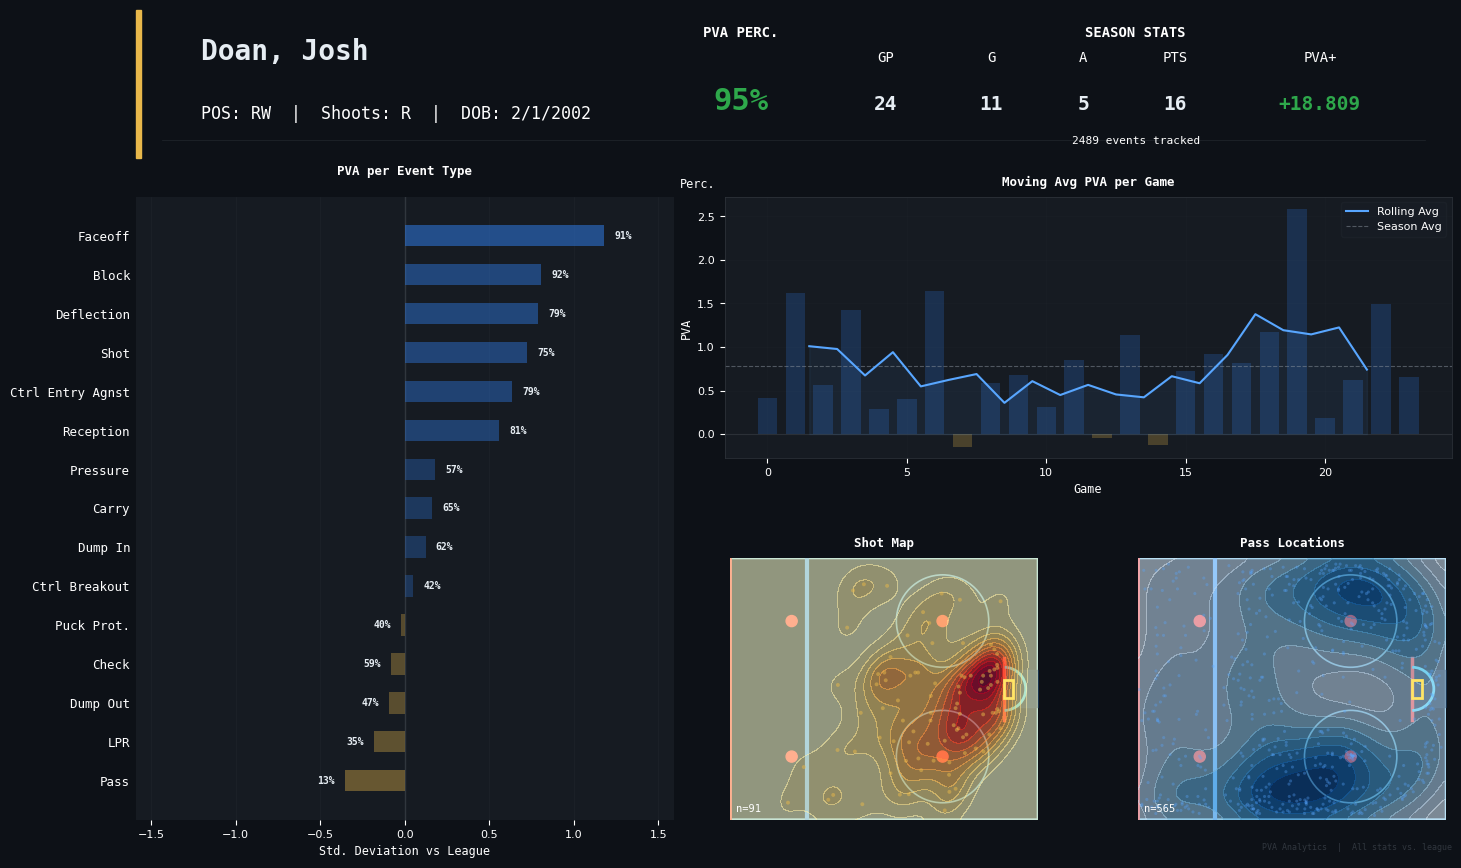

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt

plt.close('all')

fig = generate_player_card(
    events_df   = events_df,
    players_df  = players_df,
    #player_name = "Goncalves, Gage",
    player_name = "Doan, Josh",
    #player_name = ", ",
    show        = True,
)
#Get difference by subing the previous play by the one the player was in to see how much value was added
plt.close(fig)

Loading data...
  COL events  : 53357
  Forwards shown : 12 (top 12 by GP)
  Defense shown  : 6 (top 6 by GP)

✅  Heatmap saved → epv_heatmap_SYC.png
✅  Table saved   → epv_player_table_SYC.png


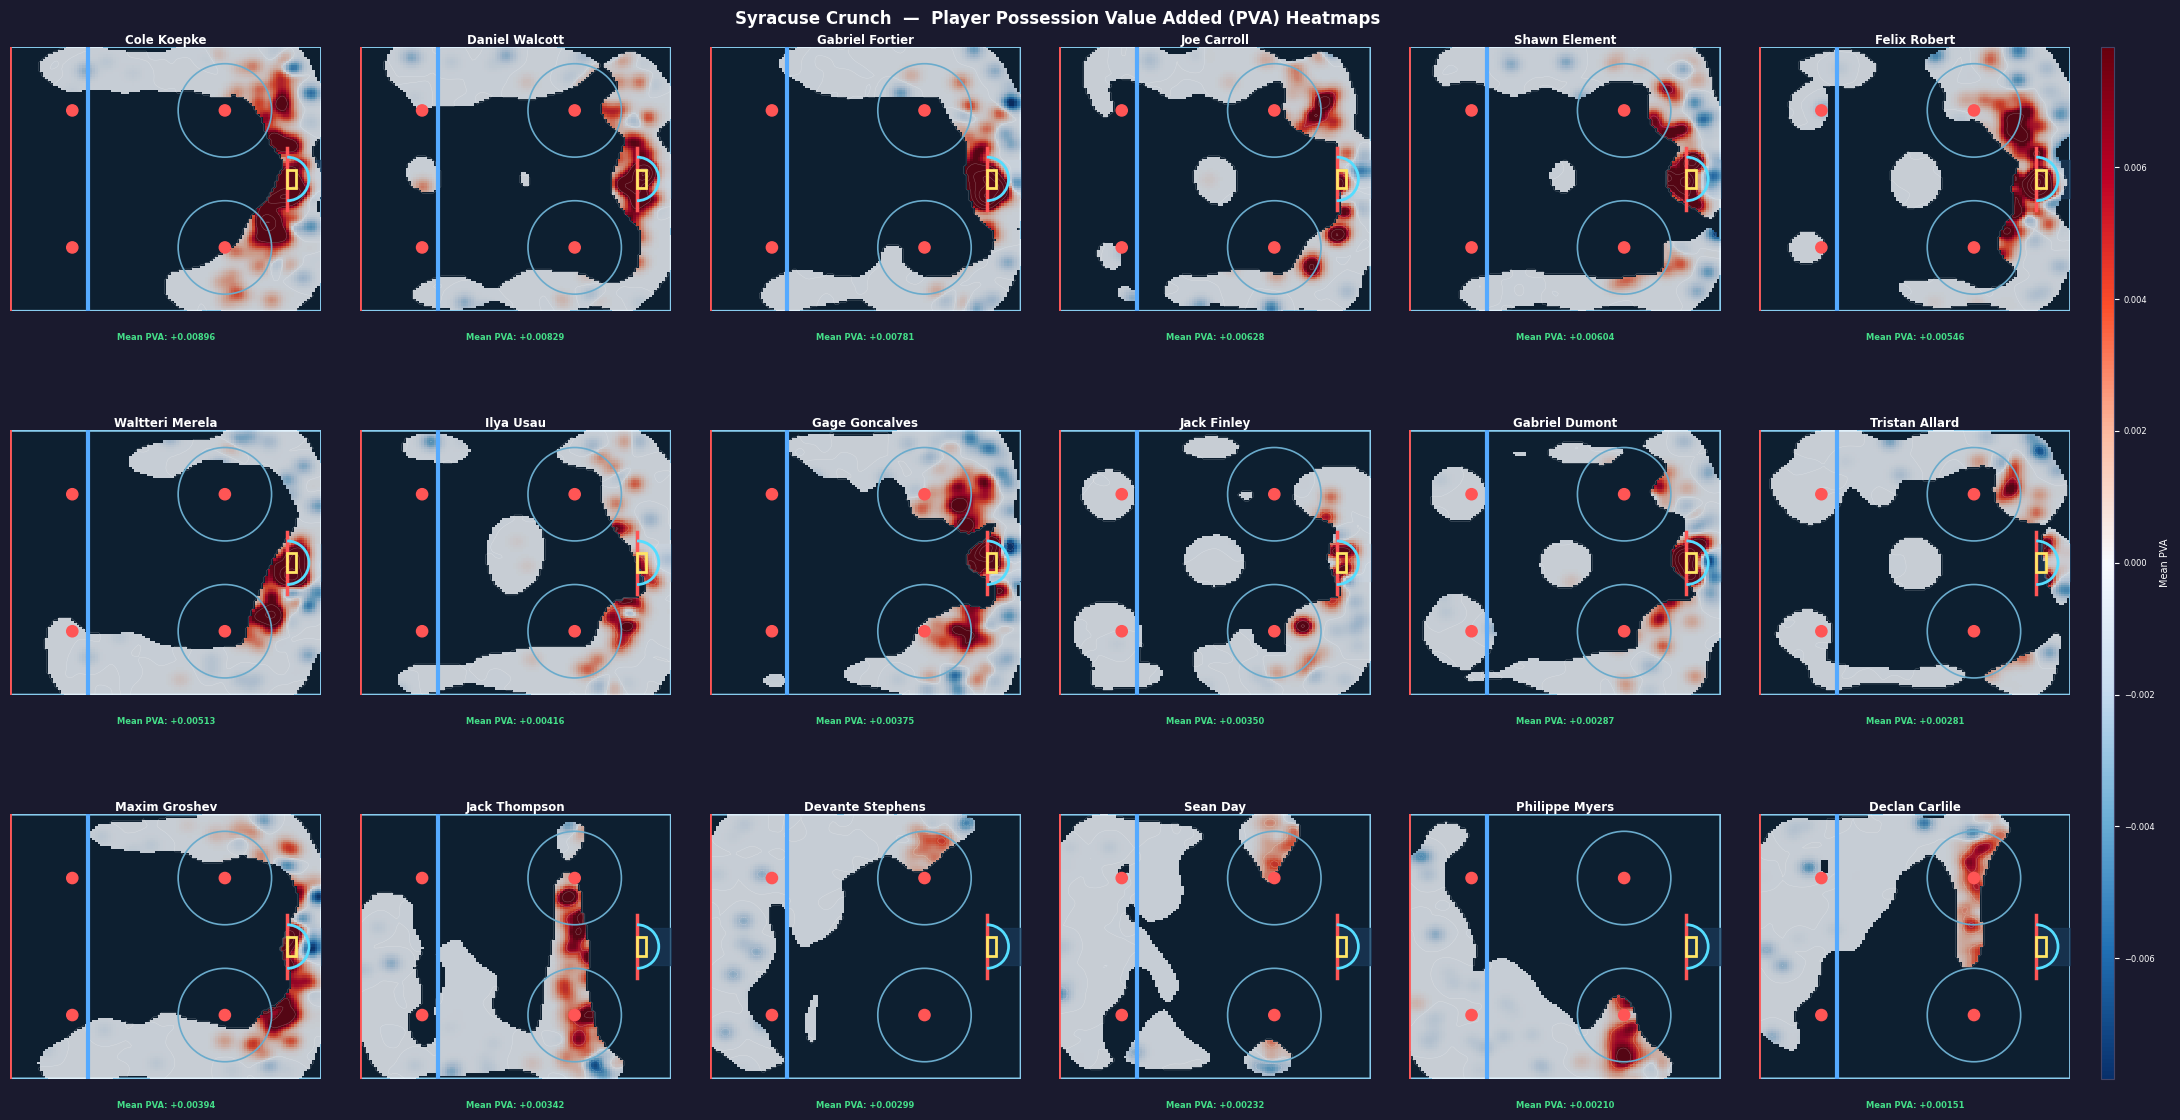

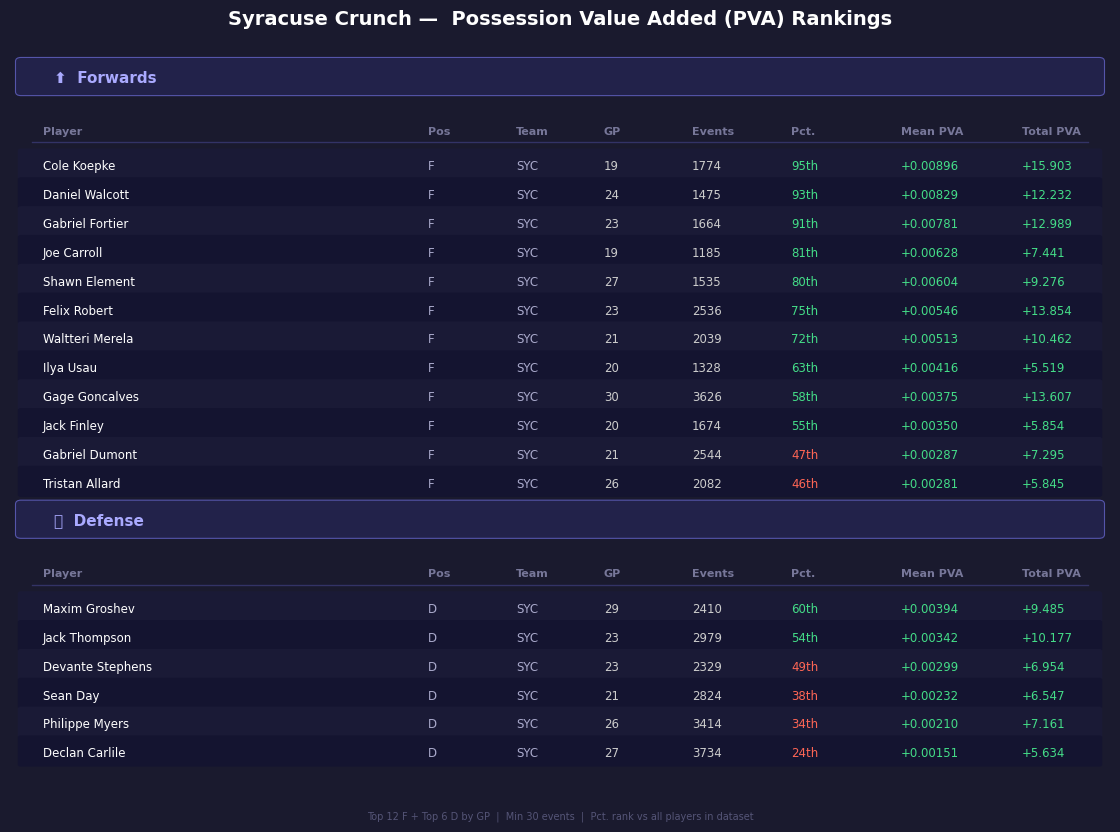

In [ ]:
"""
PVA Heatmap Visualization for Colorado Eagles (COL) Players
------------------------------------------------------------
Produces TWO output files:
  1. epv_heatmap_COL.png      — heatmap grid (one rink per player)
  2. epv_player_table_COL.png — player PVA rankings table

Shows: Top 12 Forwards + Top 6 Defensemen by games played.

Run AFTER loading in your notebook:
    events_df  = pd.read_csv('/content/drive/MyDrive/HALO Hackathon/events_with_corrected_epv.csv')
    players_df = pd.read_csv('/content/drive/MyDrive/HALO Hackathon/players(in).csv')
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import matplotlib.lines as mlines
from matplotlib.colors import TwoSlopeNorm, LinearSegmentedColormap
from scipy.ndimage import gaussian_filter
from scipy.stats import gaussian_kde

# ── 0. CONFIG ─────────────────────────────────────────────────────────────────

TEAM_FILTER    = "SYC"
OUTPUT_HEATMAP = "epv_heatmap_SYC.png"
OUTPUT_TABLE   = "epv_player_table_SYC.png"
MIN_EVENTS     = 30
GRID_RES       = 120
TOP_FORWARDS   = 12
TOP_DEFENSE    = 6

# ── 1. LOAD DATA ──────────────────────────────────────────────────────────────

print("Loading data...")
events  = events_df.copy()
players = players_df.copy()

# Keep only COL possession-team events
col_events = events[
    (events["team"] == TEAM_FILTER) &
    (events["is_possession_team_event"] == True)
].copy()

# Merge position info
col_events = col_events.merge(
    players[["player_name", "position_group", "primary_position"]],
    on="player_name", how="left"
)
col_events = col_events.dropna(subset=["x_adj", "y_adj", "delta_EPV"])

print(f"  COL events  : {len(col_events)}")

# ── 2. COORDINATE CONVERSION ─────────────────────────────────────────────────
# x_adj: -100 (own end) → +100 (opponent end), attack always RIGHT
# y_adj: already -42.5 → +42.5
# x_nhl = (x_adj + 100) / 2  maps  -100→0, 0→50, +100→100

col_events["x_nhl"] = (col_events["x_adj"] + 100) / 2
col_events["y_nhl"] = col_events["y_adj"]

# ── 3. BUILD PLAYER LISTS ─────────────────────────────────────────────────────

# Games played per player (for filtering top N by GP)
if "game_id" in col_events.columns:
    gp_per_player = (
        col_events.groupby("player_name")["game_id"]
        .nunique()
        .reset_index()
        .rename(columns={"game_id": "games_played"})
    )
else:
    # Fallback: use event count as proxy
    gp_per_player = (
        col_events.groupby("player_name")["delta_EPV"]
        .count()
        .reset_index()
        .rename(columns={"delta_EPV": "games_played"})
    )

# League-wide mean PVA for percentile calculation (all teams, all players)
league_mean_pva = (
    events_df.groupby("player_name")["delta_EPV"]
    .mean()
    .values
)

# Per-player stats for COL
player_stats = (
    col_events.groupby(["player_name", "position_group"])
    .agg(
        event_count    =("delta_EPV", "count"),
        mean_delta_epv =("delta_EPV", "mean"),
        total_delta_epv=("delta_EPV", "sum"),
    )
    .reset_index()
)
player_stats = player_stats[player_stats["event_count"] >= MIN_EVENTS]

# Merge games played
player_stats = player_stats.merge(gp_per_player, on="player_name", how="left")
player_stats["games_played"] = player_stats["games_played"].fillna(0).astype(int)

# Percentile rank vs entire league
player_stats["pct_rank"] = player_stats["mean_delta_epv"].apply(
    lambda v: int((league_mean_pva < v).mean() * 100)
)

# ── Select top N by games played per position ──
forwards_all = player_stats[player_stats["position_group"] == "F"]
defense_all  = player_stats[player_stats["position_group"] == "D"]

forwards = (forwards_all
            .sort_values("games_played", ascending=False)
            .head(TOP_FORWARDS)
            .sort_values("mean_delta_epv", ascending=False)
            .reset_index(drop=True))

defense  = (defense_all
            .sort_values("games_played", ascending=False)
            .head(TOP_DEFENSE)
            .sort_values("mean_delta_epv", ascending=False)
            .reset_index(drop=True))

all_players = pd.concat([forwards, defense]).reset_index(drop=True)

print(f"  Forwards shown : {len(forwards)} (top {TOP_FORWARDS} by GP)")
print(f"  Defense shown  : {len(defense)} (top {TOP_DEFENSE} by GP)")

# ── 4. COLOUR SETUP ───────────────────────────────────────────────────────────

full_colors = [
    "#08306b", "#2171b5", "#6baed6", "#c6dbef",
    "#f7fbff",
    "#fcbba1", "#fc4e2a", "#bd0026", "#67000d"
]
ICE_CMAP = LinearSegmentedColormap.from_list("ice_pva", full_colors, N=256)
pva_abs  = float(player_stats["mean_delta_epv"].abs().quantile(0.95))
vmax     = max(pva_abs, 0.003)
norm     = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

# ── 5. RINK DRAWING ───────────────────────────────────────────────────────────

def draw_half_rink(ax):
    """Full NHL half-rink (offensive zone right). Coords: x[0,100], y[-42.5,42.5]."""
    ax.set_xlim(0, 100)
    ax.set_ylim(-42.5, 42.5)
    ax.set_aspect("equal", adjustable="box")
    ax.axis("off")
    ax.set_facecolor("#0d1f30")
    lw = 1.0

    ax.add_patch(mpatches.FancyBboxPatch(
        (0, -42.5), 100, 85, boxstyle="round,pad=0",
        linewidth=lw * 2, edgecolor="#88CCEE",
        facecolor="#0d1f30", zorder=1
    ))
    ax.fill_between([89, 100], [-6, -6], [6, 6],
                    color="#1A3A5A", alpha=0.7, zorder=2)
    ax.add_patch(mpatches.Arc(
        (89, 0), 14, 14, angle=0, theta1=270, theta2=90,
        color="#55DDFF", lw=lw * 2, zorder=5
    ))
    ax.add_patch(mpatches.Rectangle(
        (89, -3), 3, 6, linewidth=lw * 2,
        edgecolor="#FFE566", facecolor="none", zorder=6
    ))
    ax.plot([89, 89], [-10, 10], color="#FF5555", lw=lw * 2.5, zorder=4)
    ax.plot([25, 25], [-42.5, 42.5], color="#55AAFF", lw=lw * 3, zorder=4)
    ax.plot([0, 0], [-42.5, 42.5], color="#FF5555", lw=lw * 2, zorder=4)
    for y in [-22, 22]:
        ax.add_patch(plt.Circle((69, y), 1.8, color="#FF5555", fill=True, zorder=5))
        ax.add_patch(mpatches.Arc(
            (69, y), 30, 30, angle=0, theta1=0, theta2=360,
            color="#6AABCC", lw=lw * 1.2, zorder=4
        ))
    for y in [-22, 22]:
        ax.add_patch(plt.Circle((20, y), 1.8, color="#FF5555", fill=True, zorder=5))

# ── 6. HEATMAP COMPUTATION ────────────────────────────────────────────────────

def compute_heatmap_kde(p_events):
    xs = p_events["x_nhl"].values
    ys = p_events["y_nhl"].values
    vs = p_events["delta_EPV"].values

    xi = np.linspace(0,     100,  GRID_RES)
    yi = np.linspace(-42.5, 42.5, GRID_RES)
    xi2d, yi2d = np.meshgrid(xi, yi)

    zi     = np.zeros((GRID_RES, GRID_RES))
    counts = np.zeros((GRID_RES, GRID_RES))
    xb = np.clip(np.digitize(xs, xi) - 1, 0, GRID_RES - 1)
    yb = np.clip(np.digitize(ys, yi) - 1, 0, GRID_RES - 1)
    for x, y, v in zip(xb, yb, vs):
        zi[y, x] += v
        counts[y, x] += 1

    with np.errstate(invalid="ignore"):
        zi_mean = np.where(counts > 0, zi / counts, np.nan)

    zi_filled = np.where(np.isnan(zi_mean), 0.0, zi_mean)
    zi_smooth = gaussian_filter(zi_filled, sigma=2.5)

    try:
        kde     = gaussian_kde(np.vstack([xs, ys]), bw_method=0.18)
        density = kde(np.vstack([xi2d.ravel(), yi2d.ravel()])).reshape(xi2d.shape)
        density = gaussian_filter(density, sigma=1.5)
        mask    = density >= np.percentile(density, 65)
    except Exception:
        count_smooth = gaussian_filter(counts.astype(float), sigma=2.5)
        mask = count_smooth > 0.3

    return xi, yi, np.where(mask, zi_smooth, np.nan)

# ══════════════════════════════════════════════════════════════════════════════
# OUTPUT 1: HEATMAP GRID
# ══════════════════════════════════════════════════════════════════════════════

N_PLAYERS = len(all_players)
N_COLS    = 6
N_ROWS    = int(np.ceil(N_PLAYERS / N_COLS))

FIG_H = max(8, N_ROWS * 3.2 + 1.5)
fig1  = plt.figure(figsize=(22, FIG_H))
fig1.patch.set_facecolor("#1a1a2e")

gs = gridspec.GridSpec(
    N_ROWS, N_COLS + 1,
    figure=fig1,
    width_ratios=[1] * N_COLS + [0.04],
    hspace=0.45, wspace=0.08,
    left=0.02, right=0.98,
    top=0.96, bottom=0.03
)

for idx, row in all_players.iterrows():
    r, c     = divmod(idx, N_COLS)
    ax       = fig1.add_subplot(gs[r, c])
    p_events = col_events[col_events["player_name"] == row["player_name"]]
    draw_half_rink(ax)

    if len(p_events) >= MIN_EVENTS:
        xi, yi, zi = compute_heatmap_kde(p_events)
        zi_m = np.ma.masked_invalid(zi)
        ax.pcolormesh(xi, yi, zi_m, cmap=ICE_CMAP, norm=norm,
                      shading="auto", zorder=2, alpha=0.80)
        zi_c = np.where(np.isnan(zi), 0.0, zi)
        try:
            ax.contour(xi, yi, zi_c, levels=4,
                       colors="white", linewidths=0.3,
                       alpha=0.35, zorder=3)
        except Exception:
            pass

    parts = row["player_name"].split(", ")
    title = f"{parts[1]} {parts[0]}" if len(parts) == 2 else row["player_name"]
    ax.set_title(title, color="white", fontsize=8.5, pad=2, fontweight="bold")

    val   = row["mean_delta_epv"]
    color = "#44dd88" if val >= 0 else "#ff6655"
    ax.text(0.5, -0.11, f"Mean PVA: {val:+.5f}",
            transform=ax.transAxes, ha="center",
            fontsize=6.0, color=color, fontweight="bold")

for idx in range(N_PLAYERS, N_ROWS * N_COLS):
    r, c = divmod(idx, N_COLS)
    fig1.add_subplot(gs[r, c]).axis("off")

cbar_ax = fig1.add_subplot(gs[:, N_COLS])
cbar_ax.set_facecolor("#1a1a2e")
sm = plt.cm.ScalarMappable(cmap=ICE_CMAP, norm=norm)
sm.set_array([])
cbar = fig1.colorbar(sm, cax=cbar_ax)
cbar.set_label("Mean PVA", color="white", fontsize=7, labelpad=4)
cbar.ax.yaxis.set_tick_params(color="white", labelsize=6)
plt.setp(cbar.ax.yaxis.get_ticklabels(), color="white")
cbar.outline.set_edgecolor("#444466")

fig1.suptitle(f"Syracuse Crunch  —  Player Possession Value Added (PVA) Heatmaps",
              color="white", fontsize=12, fontweight="bold", y=0.993)

fig1.savefig(OUTPUT_HEATMAP, dpi=150, bbox_inches="tight",
             facecolor=fig1.get_facecolor())
print(f"\n✅  Heatmap saved → {OUTPUT_HEATMAP}")

# ══════════════════════════════════════════════════════════════════════════════
# OUTPUT 2: PLAYER TOTALS TABLE
# ══════════════════════════════════════════════════════════════════════════════

def make_table_section(ax, title, df_section, y_start, line_h, col_x):
    y = y_start

    # Section header
    ax.add_patch(mpatches.FancyBboxPatch(
        (0.01, y - line_h * 0.1), 0.98, line_h * 1.05,
        boxstyle="round,pad=0.005", transform=ax.transAxes,
        facecolor="#22224a", edgecolor="#5555aa", linewidth=0.8, zorder=1
    ))
    ax.text(0.04, y + line_h * 0.38, title, transform=ax.transAxes,
            color="#aaaaff", fontsize=11, fontweight="bold", va="center")
    y -= line_h * 1.3

    # Column headers
    headers = ["Player", "Pos", "Team", "GP", "Events", "Pct.", "Mean PVA", "Total PVA"]
    for hdr, cx in zip(headers, col_x):
        ax.text(cx, y, hdr, transform=ax.transAxes,
                color="#777799", fontsize=8, va="top", fontweight="bold")
    y -= line_h * 0.55

    ax.add_line(mlines.Line2D(
        [0.02, 0.98], [y, y],
        transform=ax.transAxes, color="#333366", linewidth=1.0
    ))
    y -= line_h * 0.4

    for i, (_, p) in enumerate(df_section.iterrows()):
        bg = "#1a1a36" if i % 2 == 0 else "#141430"
        ax.add_patch(mpatches.FancyBboxPatch(
            (0.01, y - line_h * 0.82), 0.98, line_h * 0.92,
            boxstyle="round,pad=0.003", transform=ax.transAxes,
            facecolor=bg, edgecolor="none", zorder=0
        ))

        parts   = p["player_name"].split(", ")
        display = f"{parts[1]} {parts[0]}" if len(parts) == 2 else p["player_name"]

        mean_val  = p["mean_delta_epv"]
        total_val = p["total_delta_epv"]
        pct_val   = int(p["pct_rank"])
        pva_color = "#44dd88" if mean_val >= 0 else "#ff6655"
        pct_color = "#44dd88" if pct_val >= 50 else "#ff6655"

        row_vals = [
            display,
            p.get("position_group", ""),
            TEAM_FILTER,
            str(int(p["games_played"])),
            str(int(p["event_count"])),
            f"{pct_val}th",
            f"{mean_val:+.5f}",
            f"{total_val:+.3f}",
        ]
        row_cols = ["white", "#aaaacc", "#aaaacc", "#cccccc",
                    "#cccccc", pct_color, pva_color, pva_color]

        for val, cx, col in zip(row_vals, col_x, row_cols):
            ax.text(cx, y - line_h * 0.22, val, transform=ax.transAxes,
                    color=col, fontsize=8.5, va="top")

        y -= line_h

    return y - line_h * 0.5


# ── Figure sizing ──
total_players = len(forwards) + len(defense)
FIG_H2 = total_players * 0.36 + 1.8

fig2, ax2 = plt.subplots(figsize=(11, FIG_H2), facecolor="#1a1a2e")
fig2.subplots_adjust(top=0.97, bottom=0.02, left=0.0, right=1.0)
ax2.set_facecolor("#1a1a2e")
ax2.set_xlim(0, 1)
ax2.set_ylim(0, 1)
ax2.axis("off")

# Column x positions: Player, Pos, Team, GP, Events, Pct., Mean PVA, Total PVA
col_x  = [0.03, 0.38, 0.46, 0.54, 0.62, 0.71, 0.81, 0.92]

content_rows = total_players + 6
line_h = 0.88 / content_rows

fig2.suptitle("Syracuse Crunch —  Possession Value Added (PVA) Rankings",
              color="white", fontsize=14, fontweight="bold", y=0.98)

y_cursor = 0.91
y_cursor = make_table_section(ax2, "⬆  Forwards", forwards, y_cursor, line_h, col_x)
y_cursor -= line_h * 0.6
y_cursor = make_table_section(ax2, "🛡  Defense",  defense,  y_cursor, line_h, col_x)

fig2.text(0.5, 0.002,
          f"Top {TOP_FORWARDS} F + Top {TOP_DEFENSE} D by GP  |  "
          f"Min {MIN_EVENTS} events  |  Pct. rank vs all players in dataset",
          ha="center", color="#555577", fontsize=7)

fig2.savefig(OUTPUT_TABLE, dpi=150, bbox_inches="tight",
             facecolor=fig2.get_facecolor())
print(f"✅  Table saved   → {OUTPUT_TABLE}")

plt.show()

In [ ]:
col_events = events_df[events_df['team'] == 'COL'].copy()
print("x_adj:", col_events['x_adj'].describe())
print("\ny_adj:", col_events['y_adj'].describe())
print("\nSample x_adj values:", col_events['x_adj'].head(20).values)

x_adj: count    52334.000000
mean        -2.915015
std         59.291820
min        -99.384415
25%        -57.038174
50%         -0.476479
75%         46.468520
max         99.907650
Name: x_adj, dtype: float64

y_adj: count    52334.000000
mean         0.457729
std         26.557066
min        -41.997060
25%        -23.388235
50%          0.252941
75%         24.394117
max         42.500000
Name: y_adj, dtype: float64

Sample x_adj values: [ -0.2058258 -20.323471  -21.824402  -89.72146   -89.72146   -54.51558
 -56.024403  -84.69205   -90.2244    -90.72734   -75.13617   -75.13617
  17.907951  -68.60582   -56.024403  -82.177345  -77.147934  -93.24205
 -90.2244    -61.053814 ]


In [ ]:
"""
Possession PVA Plot
===================
Plots delta PVA and cumulative PVA for a single possession.

USAGE IN JUPYTER NOTEBOOK:
---------------------------
Paste this entire file into a cell, then in the next cell run:

    # Find available possession IDs:
    print(events_df['game_possession_id'].unique()[:20])

    # Plot a specific possession:
    fig = plot_possession(
        events_df     = events_df,
        possession_id = "00b0366a-95c6-5250-2dae-e3dd5c4198bc_P3",
        show          = True,
    )
"""

import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import Patch
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')


# ─────────────────────────────────────────────
#  THEME
# ─────────────────────────────────────────────
THEME = {
    'bg':         '#0D1117',
    'panel':      '#161B22',
    'panel2':     '#1C2330',
    'border':     '#30363D',
    'gold':       '#E8B84B',
    'gold_dim':   '#8B6914',
    'navy':       '#1F4E8C',
    'navy_bright':'#2D72D2',
    'red':        '#CF3030',
    'green':      '#2EA84B',
    'text':       '#E6EDF3',
    'text_dim':   '#8B949E',
    'text_faint': '#484F58',
    'white':      '#FFFFFF',
    'accent':     '#58A6FF',
}


# ─────────────────────────────────────────────
#  MAIN FUNCTION
# ─────────────────────────────────────────────

def plot_possession(
    events_df:     pd.DataFrame,
    possession_id: str,
    output_path:   str  = None,
    show:          bool = True,
) -> plt.Figure:
    """
    Plot PVA for a single possession — two panels:
      Top:    Delta PVA per event (bar chart)
      Bottom: Cumulative PVA over the possession (line chart)

    Parameters
    ----------
    events_df     : Full events DataFrame with columns:
                    game_possession_id, event_type, player_name,
                    delta_EPV, events_so_far, team, period,
                    possession_ends_in_goal
    possession_id : Exact game_possession_id string to plot.
                    Use events_df['game_possession_id'].unique()
                    to find available IDs.
    output_path   : Optional path to save PNG (e.g. "possession.png")
    show          : If True, renders inline in Jupyter notebook.

    Returns
    -------
    fig : matplotlib.figure.Figure

    Example
    -------
    print(events_df['game_possession_id'].unique()[:20])

    fig = plot_possession(
        events_df     = events_df,
        possession_id = "00b0366a-95c6-5250-2dae-e3dd5c4198bc_P3",
        show          = True,
    )
    """

    # ── Filter to possession ──
    poss = events_df[events_df['game_possession_id'] == possession_id].copy()

    if poss.empty:
        raise ValueError(
            f"Possession '{possession_id}' not found.\n"
            f"Sample IDs: {list(events_df['game_possession_id'].unique()[:5])}"
        )

    # ── Sort by event order ──
    if 'events_so_far' in poss.columns:
        poss = poss.sort_values('events_so_far').reset_index(drop=True)
    else:
        poss = poss.reset_index(drop=True)

    n_events  = len(poss)
    x         = np.arange(1, n_events + 1)
    delta_pva = poss['delta_EPV'].values
    cumul_pva = np.cumsum(delta_pva)

    # ── X-axis labels: event type + player last name ──
    def shorten_event(et):
        return (str(et)
                .replace('controlledentryagainst', 'ctrl entry agnst')
                .replace('controlledbreakout',     'ctrl breakout')
                .replace('puckprotection',         'puck prot')
                .replace('receptionprevention',    'recep. prev.'))

    labels = [
        f"{shorten_event(row.event_type)}\n{str(row.player_name).split(',')[0]}"
        for _, row in poss.iterrows()
    ]

    # ── Figure ──
    fig, (ax1, ax2) = plt.subplots(
        2, 1,
        figsize=(max(10, n_events * 0.9), 9),
        facecolor=THEME['bg']
    )
    fig.patch.set_facecolor(THEME['bg'])

    # ────────────────────────────────
    #  TOP PANEL: Delta PVA per event
    # ────────────────────────────────
    ax1.set_facecolor(THEME['panel'])
    for sp in ax1.spines.values():
        sp.set_color(THEME['border'])
        sp.set_linewidth(0.5)

    ax1.axhline(0, color=THEME['border'], lw=1, zorder=2)

    # Lollipop stems
    for xi, val in zip(x, delta_pva):
        color = THEME['navy_bright'] if val >= 0 else THEME['gold']
        ax1.plot([xi, xi], [0, val], color=color, lw=2, alpha=0.7, zorder=3)

    # Lollipop heads (connected scatter dots)
    for xi, val in zip(x, delta_pva):
        color = THEME['navy_bright'] if val >= 0 else THEME['gold']
        ax1.scatter(xi, val, color=color, s=80, zorder=5,
                    edgecolors=THEME['bg'], linewidths=1.2)

    # Connect dots with thin line
    ax1.plot(x, delta_pva, color=THEME['text_faint'],
             lw=0.8, alpha=0.4, zorder=2, linestyle='--')

    # Value labels
    y_range = max(abs(delta_pva.max()), abs(delta_pva.min())) if len(delta_pva) else 1
    for xi, val in zip(x, delta_pva):
        y_off = y_range * 0.08 if val >= 0 else -y_range * 0.08
        va    = 'bottom' if val >= 0 else 'top'
        ax1.text(xi, val + y_off, f"{val:+.4f}",
                 ha='center', va=va, fontsize=6.5,
                 color=THEME['white'], fontfamily='monospace')

    ax1.set_xticks(x)
    ax1.set_xticklabels(labels, fontsize=7.5, color=THEME['white'],
                        fontfamily='monospace', rotation=30, ha='right')
    ax1.tick_params(axis='y', colors=THEME['white'], labelsize=8)
    ax1.set_ylabel('Delta PVA', fontsize=9.5, color=THEME['white'],
                   fontfamily='monospace', labelpad=4)
    ax1.set_title('Delta PVA per Event', fontsize=12, fontweight='bold',
                  color=THEME['white'], fontfamily='monospace', pad=10)
    ax1.yaxis.grid(True, color=THEME['text_faint'], alpha=0.15, lw=0.5)
    ax1.set_axisbelow(True)
    ax1.set_xlim(0.3, n_events + 0.7)

    # Legend
    legend_elements = [
        Patch(facecolor=THEME['navy_bright'], alpha=0.85, label='Value Added'),
        Patch(facecolor=THEME['gold'],        alpha=0.85, label='Value Lost'),
    ]
    ax1.legend(handles=legend_elements, fontsize=8, loc='upper right',
               framealpha=0.2, labelcolor=THEME['white'],
               facecolor=THEME['panel2'], edgecolor=THEME['border'])

    # ────────────────────────────────
    #  BOTTOM PANEL: Cumulative PVA
    # ────────────────────────────────
    ax2.set_facecolor(THEME['panel'])
    for sp in ax2.spines.values():
        sp.set_color(THEME['border'])
        sp.set_linewidth(0.5)

    ax2.axhline(0, color=THEME['border'], lw=1, zorder=2)

    # Final value colour — defined first so scatter can use it
    final_color = THEME['green'] if cumul_pva[-1] >= 0 else THEME['red']

    # Connecting line
    ax2.plot(x, cumul_pva, color=THEME['accent'],
             lw=2, alpha=0.5, zorder=3, linestyle='-')

    # Colour each segment by direction
    for i in range(len(x) - 1):
        seg_color = THEME['navy_bright'] if cumul_pva[i+1] >= cumul_pva[i] else THEME['gold']
        ax2.plot([x[i], x[i+1]], [cumul_pva[i], cumul_pva[i+1]],
                 color=seg_color, lw=2.5, alpha=0.8, zorder=4)

    # Connected scatter dots — coloured by above/below zero
    for xi, yi in zip(x, cumul_pva):
        color = THEME['navy_bright'] if yi >= 0 else THEME['gold']
        ax2.scatter(xi, yi, color=color, s=90, zorder=6,
                    edgecolors=THEME['bg'], linewidths=1.5)

    # First and last dots highlighted
    ax2.scatter(x[0],  cumul_pva[0],  color=THEME['white'],
                s=100, zorder=7, edgecolors=THEME['bg'], linewidths=1.5)
    ax2.scatter(x[-1], cumul_pva[-1], color=final_color,
                s=120, zorder=7, edgecolors=THEME['bg'], linewidths=1.5)
    ax2.annotate(
        f"Final: {cumul_pva[-1]:+.4f}",
        xy=(x[-1], cumul_pva[-1]),
        xytext=(8, 0), textcoords='offset points',
        fontsize=8.5, color=final_color,
        fontfamily='monospace', fontweight='bold',
        va='center'
    )

    ax2.set_xticks(x)
    ax2.set_xticklabels(labels, fontsize=7.5, color=THEME['white'],
                        fontfamily='monospace', rotation=30, ha='right')
    ax2.tick_params(axis='y', colors=THEME['white'], labelsize=8)
    ax2.set_ylabel('Cumulative PVA', fontsize=9.5, color=THEME['white'],
                   fontfamily='monospace', labelpad=4)
    ax2.set_title('Cumulative PVA', fontsize=12, fontweight='bold',
                  color=THEME['white'], fontfamily='monospace', pad=10)
    ax2.yaxis.grid(True, color=THEME['text_faint'], alpha=0.15, lw=0.5)
    ax2.set_axisbelow(True)
    ax2.set_xlim(0.3, n_events + 0.7)

    # ── Main title ──
    team      = poss['team'].iloc[0]                      if 'team'   in poss.columns else ''
    period    = poss['period'].iloc[0]                    if 'period' in poss.columns else ''
    ends_goal = poss['possession_ends_in_goal'].iloc[0]   if 'possession_ends_in_goal' in poss.columns else False
    goal_str  = '  🥅 ENDS IN GOAL' if ends_goal else ''

    fig.suptitle(
        f"Possession: {possession_id}  |  Team: {team}  |  Period: {period}{goal_str}",
        fontsize=10, fontweight='bold',
        color=THEME['white'], fontfamily='monospace', y=0.99
    )

    plt.tight_layout(rect=[0, 0, 1, 0.97])

    if output_path:
        fig.savefig(output_path, dpi=150, bbox_inches='tight',
                    facecolor=THEME['bg'])
        print(f"Saved: {output_path}")

    if show:
        plt.show()

    return fig

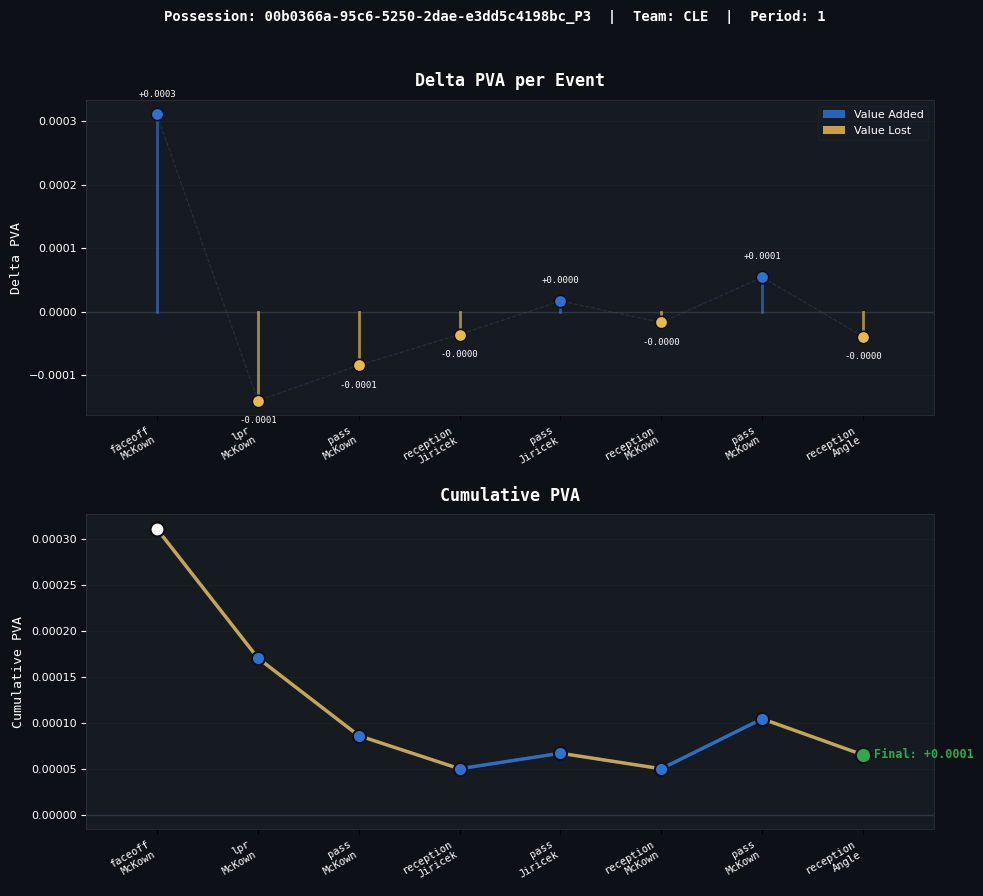

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
from IPython.display import display

plt.close('all')

fig = plot_possession(
    events_df     = events_df,
    possession_id = "00b0366a-95c6-5250-2dae-e3dd5c4198bc_P3",
    show          = False,
)

display(fig)
plt.close(fig)

In [ ]:
oil = pd.read_csv('/content/drive/MyDrive/HALO Hackathon/HALO Hackathon/consolidated_metrics.csv')
oil

,shift_id,game_id,player_id,team_id,period,period_time_start,period_time_end,total_distance_traveled,num_bursts,weighted_actions_score,...,opponent_team,position_group,shift_in_game,sfi_exp_decay_game,sfi_remaining_game_linear,next_shift_sfi,next_shift_sfi_remaining,next_shift_sfi_exp_decay_game,rest_bins,dominant_zone
0,0,09ea9787-11ed-01cd-bd3a-7ff5e7d575c9,080a4b83-a144-5887-3f0e-084a2fbeb039,be8d53f2-8cbd-df04-b9e7-0eb07a851c0a,1,117.00,123.00,483.480232,31,3.5,...,LAV,Other,1,53.505036,4.788380e+01,1.880197e+09,98.934979,53.505036,0,Neutral
1,0,09ea9787-11ed-01cd-bd3a-7ff5e7d575c9,080a4b83-a144-5887-3f0e-084a2fbeb039,be8d53f2-8cbd-df04-b9e7-0eb07a851c0a,1,117.00,123.00,483.480232,31,3.5,...,LAV,Other,1,53.505036,4.788380e+01,1.880197e+09,98.934979,53.505036,0,Neutral
2,0,09ea9787-11ed-01cd-bd3a-7ff5e7d575c9,080a4b83-a144-5887-3f0e-084a2fbeb039,be8d53f2-8cbd-df04-b9e7-0eb07a851c0a,1,117.00,123.00,483.480232,31,3.5,...,LAV,Other,1,53.505036,4.788380e+01,1.880197e+09,98.934979,53.505036,0,Neutral
3,0,09ea9787-11ed-01cd-bd3a-7ff5e7d575c9,080a4b83-a144-5887-3f0e-084a2fbeb039,be8d53f2-8cbd-df04-b9e7-0eb07a851c0a,1,117.00,123.00,483.480232,31,3.5,...,LAV,Other,1,53.505036,4.788380e+01,1.880197e+09,98.934979,53.505036,0,Neutral
4,0,09ea9787-11ed-01cd-bd3a-7ff5e7d575c9,080a4b83-a144-5887-3f0e-084a2fbeb039,be8d53f2-8cbd-df04-b9e7-0eb07a851c0a,1,117.00,123.00,483.480232,31,3.5,...,LAV,Other,1,53.505036,4.788380e+01,1.880197e+09,98.934979,53.505036,0,Neutral
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
400223,32041,fbc81a13-9708-f101-0cb7-53fac2f9a333,f9495ec1-9ceb-683b-3649-a79f99f3622d,2251a5f6-9710-c610-8d44-9f2e4f4fc7a2,3,1070.03,1072.03,136.475966,7,0.0,...,RCH,Forward Group 1 (LW/RW),13,30.119421,0.000000e+00,NaN,NaN,30.119421,0,Neutral
400224,32041,fbc81a13-9708-f101-0cb7-53fac2f9a333,f9495ec1-9ceb-683b-3649-a79f99f3622d,2251a5f6-9710-c610-8d44-9f2e4f4fc7a2,3,1070.03,1072.03,136.475966,7,0.0,...,RCH,Forward Group 1 (LW/RW),13,30.119421,0.000000e+00,NaN,NaN,30.119421,0,Neutral
400225,32042,fbc81a13-9708-f101-0cb7-53fac2f9a333,fb8b7824-cce7-967c-b477-848f6d0535cd,2251a5f6-9710-c610-8d44-9f2e4f4fc7a2,1,5.00,30.00,1.146183,0,0.0,...,RCH,Other,1,60.141229,5.762712e+01,2.202965e+00,100.000000,60.141229,0,Neutral
400226,32044,fbc81a13-9708-f101-0cb7-53fac2f9a333,fb8b7824-cce7-967c-b477-848f6d0535cd,2251a5f6-9710-c610-8d44-9f2e4f4fc7a2,2,0.00,19.03,1.146183,0,0.0,...,RCH,Other,3,60.141229,5.762712e+01,2.479946e-01,100.000000,60.141229,0,Neutral


In [ ]:
"""
PVA vs OIL Scatter Plot
========================
Plots total PVA per shift against OIL (oil_track) per shift.
One dot per shift. Shows whether PVA holds up regardless of OIL quality.

USAGE IN JUPYTER NOTEBOOK:
---------------------------
Paste this entire file into a cell, then in the next cell run:

    fig = plot_pva_vs_oil(
        events_df  = events_df,
        oil_df     = oil,
        player_name = "McKown, Hunter",   # optional — highlights one player
        show        = True,
    )
"""

import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import pandas as pd
from scipy.stats import gaussian_kde
from scipy.ndimage import gaussian_filter
import warnings
warnings.filterwarnings('ignore')


THEME = {
    'bg':         '#0D1117',
    'panel':      '#161B22',
    'panel2':     '#1C2330',
    'border':     '#30363D',
    'gold':       '#E8B84B',
    'gold_dim':   '#8B6914',
    'navy':       '#1F4E8C',
    'navy_bright':'#2D72D2',
    'red':        '#CF3030',
    'green':      '#2EA84B',
    'text':       '#E6EDF3',
    'text_dim':   '#8B949E',
    'text_faint': '#484F58',
    'white':      '#FFFFFF',
    'accent':     '#58A6FF',
}


def plot_pva_vs_oil(
    events_df:   pd.DataFrame,
    oil_df:      pd.DataFrame,
    players_df:  pd.DataFrame = None,
    player_name: str  = None,
    oil_col:     str  = 'oil_track',
    output_path: str  = None,
    show:        bool = True,
) -> plt.Figure:
    """
    Scatter plot of total PVA per shift vs OIL quality per shift.
    Shows whether PVA holds up regardless of on-ice load.

    Parameters
    ----------
    events_df   : Events DataFrame with game_id, player_name, delta_EPV
    oil_df      : OIL DataFrame with player_id, game_id, shift_id, oil_track
    players_df  : Players DataFrame with player_id + player_name columns.
                  Required if oil_df does not already have a player_name column.
    player_name : Optional — highlights this player's shifts in gold
    oil_col     : OIL metric column to use (default: 'oil_track')
    output_path : Optional path to save PNG
    show        : If True, renders inline in Jupyter

    Returns
    -------
    fig : matplotlib.figure.Figure

    Example
    -------
    fig = plot_pva_vs_oil(
        events_df   = events_df,
        oil_df      = oil,
        player_name = "McKown, Hunter",
        show        = True,
    )
    """

    # ── Step 1: Compute total PVA per player per game (shift proxy) ──
    # events_df has player_name + game_id + delta_EPV
    # oil_df has player_id + game_id + shift_id + oil_track
    # We join on game_id + player_id via player_name lookup

    # Aggregate PVA per player per game
    pva_per_game = (
        events_df.groupby(['player_name', 'game_id'])['delta_EPV']
        .sum()
        .reset_index()
        .rename(columns={'delta_EPV': 'total_pva'})
    )

    # Get player_name into oil_df if not already there
    oil_clean = oil_df.copy()

    # Drop rows with missing or infinite oil values
    oil_clean = oil_clean.replace([np.inf, -np.inf], np.nan)
    oil_clean = oil_clean.dropna(subset=[oil_col])

    # If player_name not in oil_df, map it from players_df via player_id
    if 'player_name' not in oil_clean.columns:
        if players_df is not None and 'player_id' in oil_clean.columns:
            id_to_name = (
                players_df[['player_id', 'player_name']]
                .drop_duplicates()
                .set_index('player_id')['player_name']
                .to_dict()
            )
            oil_clean['player_name'] = oil_clean['player_id'].map(id_to_name)
        else:
            raise KeyError(
                "oil_df does not have a 'player_name' column.\n"
                "Pass players_df so the player_id -> player_name mapping can be made:\n"
                "  plot_pva_vs_oil(events_df=events_df, oil_df=oil, players_df=players_df, ...)\n"
                "Or add it manually:\n"
                "  oil['player_name'] = oil['player_id'].map(players_df.set_index('player_id')['player_name'])"
            )

    # Aggregate oil per player per game (mean oil_track across shifts in that game)
    oil_per_game = (
        oil_clean.groupby(['player_name', 'game_id'])[oil_col]
        .mean()
        .reset_index()
        .rename(columns={oil_col: 'avg_oil'})
    )

    # ── Step 2: Merge PVA + OIL ──
    merged = pva_per_game.merge(oil_per_game, on=['player_name', 'game_id'], how='inner')
    merged = merged.dropna(subset=['total_pva', 'avg_oil'])

    if merged.empty:
        raise ValueError(
            "No matching rows after merging events_df and oil_df on "
            "player_name + game_id. Check that both DataFrames have "
            "matching player_name and game_id values."
        )

    x_all = merged['avg_oil'].values
    y_all = merged['total_pva'].values

    # ── Step 3: Figure ──
    fig, ax = plt.subplots(figsize=(12, 8), facecolor=THEME['bg'])
    fig.patch.set_facecolor(THEME['bg'])
    ax.set_facecolor(THEME['panel'])
    for sp in ax.spines.values():
        sp.set_color(THEME['border'])
        sp.set_linewidth(0.8)

    # ── Background density (all players) ──
    if len(x_all) > 10:
        try:
            xi = np.linspace(x_all.min(), x_all.max(), 120)
            yi = np.linspace(y_all.min(), y_all.max(), 120)
            xi2d, yi2d = np.meshgrid(xi, yi)
            kde = gaussian_kde(np.vstack([x_all, y_all]), bw_method=0.3)
            zi  = kde(np.vstack([xi2d.ravel(), yi2d.ravel()])).reshape(xi2d.shape)
            zi  = gaussian_filter(zi, sigma=2)
            ax.contourf(xi, yi, zi, levels=10, cmap='Blues', alpha=0.18, zorder=1)
        except Exception:
            pass

    # ── All player dots ──
    highlight_mask = np.zeros(len(merged), dtype=bool)
    if player_name:
        highlight_mask = (merged['player_name'] == player_name).values

    ax.scatter(
        x_all[~highlight_mask], y_all[~highlight_mask],
        color=THEME['navy_bright'], alpha=0.35, s=25,
        edgecolors='none', zorder=3, label='All players'
    )

    # ── Trend line (all players) ──
    if len(x_all) > 5:
        z    = np.polyfit(x_all, y_all, 1)
        p    = np.poly1d(z)
        x_line = np.linspace(x_all.min(), x_all.max(), 200)
        ax.plot(x_line, p(x_line), color=THEME['accent'],
                lw=2, alpha=0.7, zorder=4, linestyle='--', label='Trend')

        # Correlation annotation
        corr = np.corrcoef(x_all, y_all)[0, 1]
        ax.text(0.97, 0.97, f"r = {corr:.3f}",
                transform=ax.transAxes, ha='right', va='top',
                fontsize=10, color=THEME['accent'],
                fontfamily='monospace', fontweight='bold')

    # ── Highlighted player dots ──
    if player_name and highlight_mask.any():
        ax.scatter(
            x_all[highlight_mask], y_all[highlight_mask],
            color=THEME['gold'], alpha=0.9, s=70,
            edgecolors=THEME['bg'], linewidths=1.2,
            zorder=6, label=player_name
        )
        # Player trend line
        xp = x_all[highlight_mask]
        yp = y_all[highlight_mask]
        if len(xp) > 2:
            zp    = np.polyfit(xp, yp, 1)
            pp    = np.poly1d(zp)
            xp_line = np.linspace(xp.min(), xp.max(), 100)
            ax.plot(xp_line, pp(xp_line), color=THEME['gold'],
                    lw=2, alpha=0.8, zorder=5, linestyle='-')
            corr_p = np.corrcoef(xp, yp)[0, 1]
            ax.text(0.97, 0.90, f"r ({player_name.split(',')[0]}) = {corr_p:.3f}",
                    transform=ax.transAxes, ha='right', va='top',
                    fontsize=9, color=THEME['gold'],
                    fontfamily='monospace', fontweight='bold')

    # ── Zero lines ──
    ax.axhline(0, color=THEME['border'], lw=1, alpha=0.8, zorder=2)
    ax.axvline(0, color=THEME['border'], lw=1, alpha=0.8, zorder=2)

    # ── Quadrant labels ──
    x_mid = np.median(x_all)
    y_mid = 0
    quad_kw = dict(fontsize=8, alpha=0.35, fontfamily='monospace',
                   transform=ax.transData)
    ax.text(x_all.max() * 0.85, y_all.max() * 0.85,
            'High OIL\nHigh PVA', color=THEME['green'],   ha='center', **quad_kw)
    ax.text(x_all.max() * 0.85, y_all.min() * 0.85,
            'High OIL\nLow PVA',  color=THEME['red'],     ha='center', **quad_kw)
    ax.text(x_all.min() * 0.85 if x_all.min() < 0 else x_all.max() * 0.15,
            y_all.max() * 0.85,
            'Low OIL\nHigh PVA',  color=THEME['accent'],  ha='center', **quad_kw)
    ax.text(x_all.min() * 0.85 if x_all.min() < 0 else x_all.max() * 0.15,
            y_all.min() * 0.85,
            'Low OIL\nLow PVA',   color=THEME['text_dim'], ha='center', **quad_kw)

    # ── Labels ──
    ax.set_xlabel('OIL (On-Ice Load) — Avg per Game',
                  fontsize=11, color=THEME['white'],
                  fontfamily='monospace', labelpad=6)
    ax.set_ylabel('Total PVA (Possession Value Added) per Game',
                  fontsize=11, color=THEME['white'],
                  fontfamily='monospace', labelpad=6)
    ax.tick_params(colors=THEME['white'], labelsize=9)

    ax.set_title('PVA vs OIL — Does Possession Value Added Hold Up Under Load?',
                 fontsize=13, fontweight='bold',
                 color=THEME['white'], fontfamily='monospace', pad=12)

    ax.legend(fontsize=9, loc='upper left', framealpha=0.25,
              labelcolor=THEME['white'], facecolor=THEME['panel2'],
              edgecolor=THEME['border'])

    ax.xaxis.grid(True, color=THEME['text_faint'], alpha=0.12, lw=0.5)
    ax.yaxis.grid(True, color=THEME['text_faint'], alpha=0.12, lw=0.5)
    ax.set_axisbelow(True)

    # Sample size
    fig.text(0.99, 0.01, f"n = {len(merged)} player-game observations",
             ha='right', va='bottom', fontsize=7.5,
             color=THEME['text_faint'], fontfamily='monospace')

    if output_path:
        fig.savefig(output_path, dpi=150, bbox_inches='tight',
                    facecolor=THEME['bg'])
        print(f"Saved: {output_path}")

    if show:
        plt.show()

    return fig

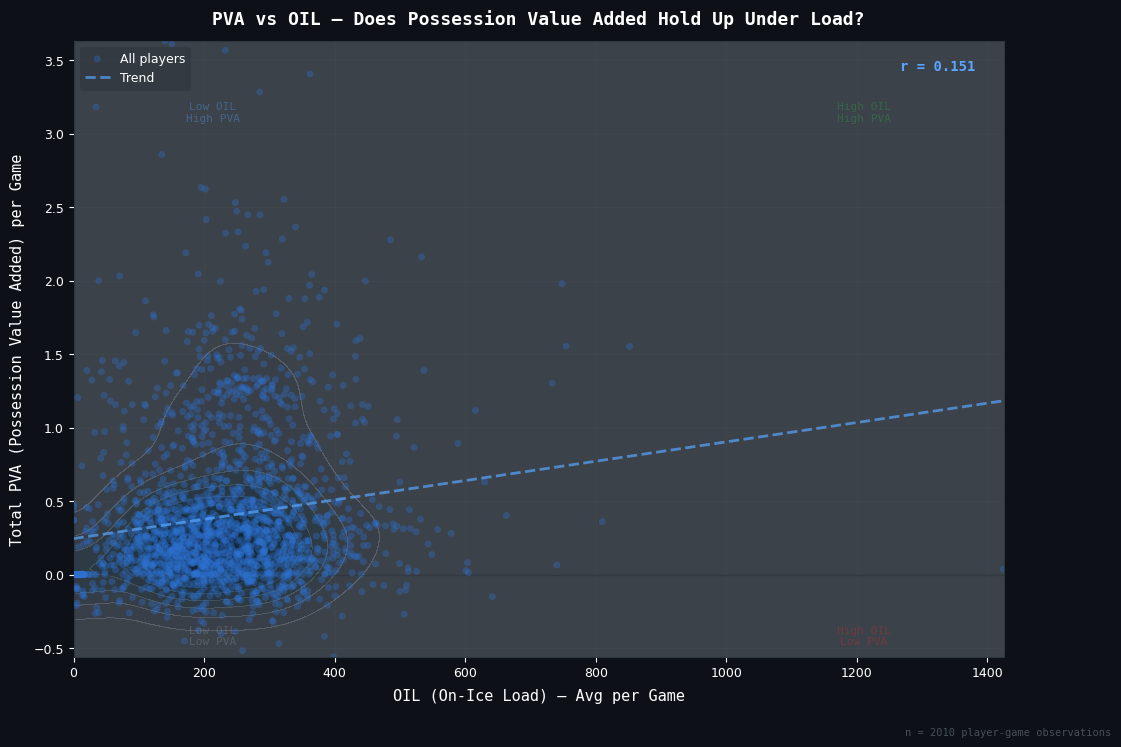

In [ ]:
%matplotlib inline



fig = plot_pva_vs_oil(
    events_df   = events_df,
    oil_df      = oil,
    players_df  = players_df,
    show        = True,
)